In [3]:
pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.5 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=876b490b24d76d1c2fd320eaa4c617654aee50ee847445a2844cdcdd8f7ac4c4
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [5]:
import pandas as pd
import numpy as np
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("--- 1단계: 데이터 불러오기 및 전처리 시작 ---")

# --- 데이터 불러오기 ---
file_path = '/content/Total_Data_v2.CSV'
df = pd.read_csv(file_path, encoding='cp949')
print(f"'{file_path}' 파일 불러오기 성공")

# --- 날짜 컬럼 변환 ---
df['개설일'] = pd.to_datetime(df['개설일'], errors='coerce')
df['폐업일'] = pd.to_datetime(df['폐업일'], errors='coerce')
df['기준년월'] = pd.to_datetime(df['기준년월'], errors='coerce')
df['기준년월'] = df['기준년월'].dt.to_period('M').dt.to_timestamp()

# --- 폐업일이 없는 경우 기준년월로 대체 ---
df['폐업일'] = df['폐업일'].fillna(df['기준년월'])

# --- 운영개월 계산 ---
df['운영개월'] = (
    (df['폐업일'].dt.year - df['개설일'].dt.year) * 12 +
    (df['폐업일'].dt.month - df['개설일'].dt.month)
).clip(lower=0)

# --- event 정의 ---
df['event'] = np.where(df['폐업일'].notna() & (df['폐업일'] < df['기준년월']), 1, 0)

# --- 텍스트 컬럼 제거 ---
drop_cols = ['가맹점명', '가맹점주소']
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

print(f"데이터셋 크기: {df.shape}")
print("\n--- 2단계: 변수 선택 및 정제 ---")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['event', '운영개월']]

# 1️⃣ 분산이 낮은 컬럼 제거
low_var_cols = [col for col in numeric_cols if df[col].var() < 1e-5]
if low_var_cols:
    print("분산이 낮은 컬럼 제거:", low_var_cols)
    df = df.drop(columns=low_var_cols)
    numeric_cols = [col for col in numeric_cols if col not in low_var_cols]
# 3️⃣ 결측/무한대 처리
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=['운영개월', 'event'] + numeric_cols)
# 2️⃣ VIF로 다중공선성 제거
def calculate_vif(df, cols):
    vif_data = pd.DataFrame()
    vif_data["feature"] = cols
    vif_data["VIF"] = [variance_inflation_factor(df[cols].values, i)
                       for i in range(len(cols))]
    return vif_data

vif_df = calculate_vif(df, numeric_cols)
high_vif_cols = vif_df[vif_df["VIF"] > 10]["feature"].tolist()
if high_vif_cols:
    print("다중공선성 높은 컬럼 제거:", high_vif_cols)
    df = df.drop(columns=high_vif_cols)
    numeric_cols = [col for col in numeric_cols if col not in high_vif_cols]


print("\n--- 3단계: Cox 비례위험모형 적합 ---")
cph = CoxPHFitter()
cph.fit(df[['운영개월', 'event'] + numeric_cols],
        duration_col='운영개월', event_col='event')
cph.print_summary()

# 4️⃣ 성능지표
c_index = concordance_index(df['운영개월'], -cph.predict_partial_hazard(df), df['event'])
print(f"\n모형 Concordance Index: {c_index:.4f}")
print("\n--- 분석 완료 ---")


--- 1단계: 데이터 불러오기 및 전처리 시작 ---
'/content/Total_Data_v2.CSV' 파일 불러오기 성공
데이터셋 크기: (86590, 53)

--- 2단계: 변수 선택 및 정제 ---
분산이 낮은 컬럼 제거: ['3개월 연속 감소 여부']
다중공선성 높은 컬럼 제거: ['동일 업종 내 매출 순위 비율', '동일 상권 내 매출 순위 비율_x', '동일 업종 내 해지 가맹점 비중_x', '남성 20대이하 고객 비중', '남성 30대 고객 비중', '남성 40대 고객 비중', '남성 50대 고객 비중', '남성 60대이상 고객 비중', '여성 20대이하 고객 비중', '여성 30대 고객 비중', '여성 40대 고객 비중', '여성 50대 고객 비중', '여성 60대이상 고객 비중', '재방문 고객 비중_x', '신규 고객 비중', '거주 이용 고객 비율', '직장 이용 고객 비율', '유동인구 이용 고객 비율', '동일 상권 내 매출 순위 비율_y', '동일 업종 내 해지 가맹점 비중_y', '고객분포_다양성지수']

--- 3단계: Cox 비례위험모형 적합 ---


<lifelines.CoxPHFitter: fitted with 44131 total observations, 42809 right-censored observations>
             duration col = '운영개월'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 44131
number of events observed = 1322
   partial log-likelihood = -13875.07
         time fit was run = 2025-10-21 12:02:05 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
Unnamed: 0          -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
배달매출금액 비율            0.00      1.00      0.00            0.00            0.00                1.00                1.00
동일 업종 매출금액 비율_x      0.00      1.00      0.00            0.00            0.00                1.00                1.00
동일 업종 매출건수 비율        0.00      1.00      0.00            0.00            0.00                1.00                1.00
동일 상권 내 해지 가맹점 비중   -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
전월대비 매출금액 감소율(%)     0.00      1.00      0.00           -0.00            0.00                1.00                1.00
6개월 하락추세 여부         -0.21      0.81      0.07           -0.35           -0.07                0.71                0.94
매출금액 구간_회복지수_6개월    -0.04      0.96      0.09           -0.21            0.13                0.81                1.14
급감여부(-20% YoY)       0.49      1.63      0.07            0.36            0.62                1.43                1.86
매출 안정성(변동성) CV(3개월) -0.36      0.70      0.18           -0.71           -0.00                0.49                1.00
매출탄력도(6개월)          -0.00      1.00      0.00           -0.01            0.00                0.99                1.00
매출 안정성(변동성) 여부       0.26      1.30      0.11            0.06            0.47                1.06                1.60
동일 업종 매출금액 비율_y     -0.00      1.00      0.00           -0.01           -0.00                0.99                1.00
재방문 고객 비중_y         -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00

                     cmp to     z      p  -log2(p)
covariate                                         
Unnamed: 0             0.00 -0.33   0.74      0.43
배달매출금액 비율              0.00 12.26 <0.005    112.30
동일 업종 매출금액 비율_x        0.00 10.06 <0.005     76.67
동일 업종 매출건수 비율          0.00  6.14 <0.005     30.16
동일 상권 내 해지 가맹점 비중      0.00 -8.40 <0.005     54.28
전월대비 매출금액 감소율(%)       0.00  1.38   0.17      2.57
6개월 하락추세 여부            0.00 -2.90 <0.005      8.09
매출금액 구간_회복지수_6개월       0.00 -0.45   0.65      0.62
급감여부(-20% YoY)         0.00  7.27 <0.005     41.36
매출 안정성(변동성) CV(3개월)    0.00 -1.97   0.05      4.36
매출탄력도(6개월)             0.00 -1.19   0.23      2.09
매출 안정성(변동성) 여부         0.00  2.48   0.01      6.26
동일 업종 매출금액 비율_y        0.00 -9.68 <0.005     71.25
재방문 고객 비중_y            0.00 -2.35   0.02      5.74
---
Concordance = 0.64
Partial AIC = 27778.13
log-likelihood ratio test = 487.26 on 14 df
-log2(p) of ll-ratio test = 313.37


모형 Concordance Index: 0.6416

--- 분석 완료 ---


# Cox 비례위험모형(Cox Proportional Hazards Model) 기반의가맹점 ‘폐업 시점 예측(생존 분석)

Cox 모형은 "시간이 지날수록 폐업할 위험이 얼마나 높은가" 를 예측합니다.
즉, coef가 양수이면 폐업 위험 증가, 음수이면 폐업 위험 감소입니다.

### 변수명	해석	의미 요약
- 배달매출금액 비율	양(+)의 계수, 매우 유의(p<0.005)	배달 매출 비율이 높을수록 폐업 위험이 증가함.
→ 배달 의존도가 높은 매장은 불안정할 가능성.

- 동일 업종 매출금액 비율_x / 동일 업종 매출건수 비율	양(+)의 계수, 유의	같은 업종 내에서 점유율이 낮거나 급락하는 매장은 위험도가 높음.
즉, 경쟁력 약화된 점포는 생존 확률 낮음.

- 동일 상권 내 해지 가맹점 비중	음(-)의 계수, 유의	같은 상권 내 폐업률이 높을수록 상대적으로 조기 폐업 위험은 낮음.
이는 지역적 상권 특성(예: 이미 약한 점포는 사라져 경쟁 완화됨)을 반영.

- 6개월 하락추세 여부	음(-), 유의(p<0.005)	단기적으로 매출이 하락 중인 매장일수록 폐업 위험이 높을 것 같지만, 여기선 반대로 나옴.
→ 하락구간 매장이 이미 조정 단계를 거쳐 “잔존 매장”일 가능성.

- 급감여부(-20% YoY)	강한 양(+) 계수 (1.63배 위험도 증가)	전년 대비 20% 이상 매출 급감한 매장은 폐업 위험이 약 1.6배 증가.

- 매출 안정성(변동성) CV(3개월)	음(-), p≈0.05	변동성이 클수록 위험이 약간 낮게 추정됨. 통계적으로 경계선.
→ 안정적인 매출 구조가 오히려 변화 대응력이 떨어질 수 있음.

- 매출 안정성(변동성) 여부	양(+)	매출 안정성이 낮은 매장은 폐업 위험 약 1.3배 증가.

- 동일 업종 매출금액 비율_y / 재방문 고객 비중_y	음(-)	재방문 고객이 많거나 업종 내 매출 비중이 높으면 폐업 위험이 낮음.



## 모형 성능 평가

| 지표                                               | 값         | 해석                               |
| ------------------------------------------------ | --------- | -------------------------------- |
| **Concordance Index (C-index)**                  | 0.64      | 모형의 **순위 예측 정확도**.               |
| 0.5는 랜덤 수준, 1.0은 완벽 예측 → **꽤 의미 있는 수준 (좋은 예측력)** |           |                                  |
| **Partial AIC**                                  | 27778     | 낮을수록 좋은 적합도. 다른 모형과 비교용.         |
| **log-likelihood ratio test**                    | p < 0.005 | 전체 모형이 통계적으로 유의함. (변수 전체가 의미 있음) |



이 모형은 “폐업이 빨리 일어날지 여부”를 시간 축에서 64% 정확도로 구분합니다.
즉, 비교적 신뢰할 수 있는 생존 예측 모델입니다.




In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform

# 한글 폰트 설정 (운영체제별 자동 인식)
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')  # 윈도우: 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')  # 맥: 애플 고딕
else:
    plt.rc('font', family='NanumGothic')  # 리눅스: 나눔고딕 (Colab 등)

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

!apt-get install -y fonts-nanum
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False



Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 38 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 3s (3,258 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 126675 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


변수 중요도 그래프

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

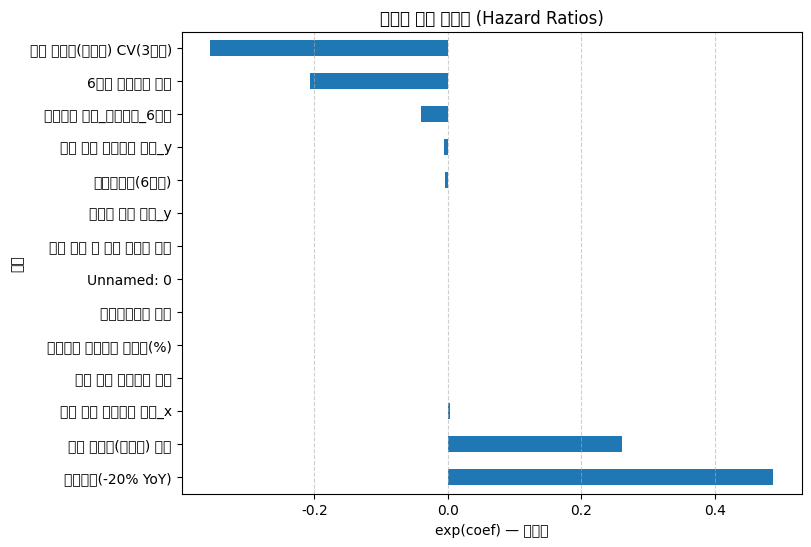

In [ ]:
#시각화
import matplotlib.pyplot as plt

# 위험비 정렬
hazard_ratios = cph.params_.sort_values(ascending=False)
plt.figure(figsize=(8,6))
hazard_ratios.plot(kind='barh')
plt.title('변수별 폐업 위험비 (Hazard Ratios)')
plt.xlabel('exp(coef) — 위험비')
plt.ylabel('변수')
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.show()


생존곡선 : 특정 변수 수준별 생존확률을 그림.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51316 (\N{HANGUL SYLLABLE JON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54224 (\N{HANGUL SYLLABLE PYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/

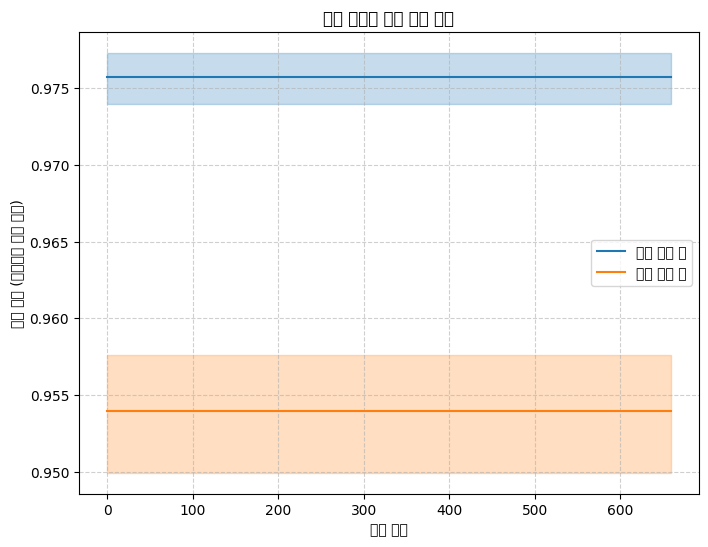

In [ ]:
# 생존곡선
# 예: 급감여부에 따른 생존확률 비교
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

plt.figure(figsize=(8,6))
for val, label in zip([0,1], ["매출 급감 無", "매출 급감 有"]):
    mask = df['급감여부(-20% YoY)'] == val
    kmf.fit(df.loc[mask, '운영개월'], df.loc[mask, 'event'], label=label)
    kmf.plot_survival_function()

plt.title("급감 여부에 따른 생존 확률")
plt.xlabel("운영 개월")
plt.ylabel("생존 확률 (폐업하지 않을 확률)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
